In [ ]:
# ============================================================
# Run thermalized-state sweep over temperature and density
# ============================================================

import time
import importlib
import numpy as np
import pandas as pd

import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT

# Reload helpers in case you just edited Logging_Helpers.py
importlib.reload(lh)
importlib.reload(sh)


# ============================================================
# Sweep settings
# ============================================================

BoxLength = 50.0

kT_values = np.round(
    np.arange(0.70, 1.00 + 0.001, 0.02),
    2,
)

rho_values = np.round(
    np.arange(0.50, 0.80 + 0.001, 0.02),
    2,
)

nsteps = 1_000_000
log_period = 1_000

overwrite = False
# Change to True only if you want to rerun simulations that already exist.


# ============================================================
# Summary CSV path
# ============================================================

summary_folder = THERMALIZED_STATES_ROOT / f"BoxLength_{BoxLength:.1f}"
summary_folder.mkdir(parents=True, exist_ok=True)

summary_path = (
    summary_folder
    / "sweep_summary_kT_0.70_1.00_rho_0.50_0.80_nsteps_1000000.csv"
)


# ============================================================
# Run sweep
# ============================================================

rows = []

total_runs = len(kT_values) * len(rho_values)
run_counter = 0

sweep_start = time.time()

for kT in kT_values:
    for rho in rho_values:
        run_counter += 1

        print("\n" + "=" * 80)
        print(f"Run {run_counter} / {total_runs}")
        print(f"BoxLength = {BoxLength:.1f}")
        print(f"kT        = {kT:.2f}")
        print(f"rho       = {rho:.2f}")
        print(f"nsteps    = {nsteps:,}")
        print(f"log_period = {log_period:,}")
        print("=" * 80)

        run_start = time.time()

        row = {
            "BoxLength": BoxLength,
            "kT": kT,
            "target_rho": rho,
            "nsteps": nsteps,
            "log_period": log_period,
            "status": "not_started",
        }

        try:
            # ====================================================
            # Create or load thermalized state
            # ====================================================

            result = sh.get_or_make_thermalized_state(
                BoxLength=BoxLength,
                target_rho=rho,
                kT=kT,
                nsteps=nsteps,
                log_period=log_period,
                lattice_type="fcc",
                overwrite=overwrite,
            )

            paths = result["paths"]

            log_path = paths["log_path"]
            state_path = paths["state_path"]

            # ====================================================
            # Read HDF5 log once
            # ====================================================

            log = lh.read_hdf5_log(log_path)

            # ====================================================
            # Compute last-100 logged-value statistics
            # ====================================================

            pressure_stats = lh.get_log_tail_stats(
                log=log,
                quantity="pressure",
                n_last=100,
            )

            pe_per_particle_stats = lh.get_log_tail_stats(
                log=log,
                quantity="PE_per_particle",
                n_last=100,
            )

            ke_per_particle_stats = lh.get_log_tail_stats(
                log=log,
                quantity="KE_per_particle",
                n_last=100,
            )

            # ====================================================
            # Get phase-separated flag from metadata
            # ====================================================

            phase_separated = log["metadata"]["attrs"].get(
                "phase_separated",
                None,
            )

            if phase_separated is not None:
                phase_separated = bool(phase_separated)

            run_time_seconds = time.time() - run_start

            # ====================================================
            # Save row information
            # ====================================================

            row.update(
                {
                    "status": "completed",
                    "created_new": result["created_new"],

                    "state_path": str(state_path),
                    "log_path": str(log_path),

                    "N": pe_per_particle_stats["N"],
                    "phase_separated": phase_separated,

                    "pressure_mean_last100": pressure_stats["mean"],
                    "pressure_std_last100": pressure_stats["std"],

                    "PE_per_particle_mean_last100": pe_per_particle_stats["mean"],
                    "PE_per_particle_std_last100": pe_per_particle_stats["std"],

                    "KE_per_particle_mean_last100": ke_per_particle_stats["mean"],
                    "KE_per_particle_std_last100": ke_per_particle_stats["std"],

                    "first_timestep_used": pressure_stats["first_timestep_used"],
                    "last_timestep_used": pressure_stats["last_timestep_used"],

                    "run_time_seconds": run_time_seconds,
                }
            )

            print("Completed")
            print("Created new:", result["created_new"])
            print("Phase separated:", phase_separated)
            print("State file: ", state_path)
            print("Log file:   ", log_path)
            print(f"Runtime:    {run_time_seconds:.2f} seconds")

            print("Final last-100 stats:")
            print(f"  pressure mean = {pressure_stats['mean']}")
            print(f"  pressure std  = {pressure_stats['std']}")
            print(f"  PE/N mean     = {pe_per_particle_stats['mean']}")
            print(f"  PE/N std      = {pe_per_particle_stats['std']}")
            print(f"  KE/N mean     = {ke_per_particle_stats['mean']}")
            print(f"  KE/N std      = {ke_per_particle_stats['std']}")

        except Exception as e:
            run_time_seconds = time.time() - run_start

            row.update(
                {
                    "status": "failed",
                    "error": str(e),
                    "run_time_seconds": run_time_seconds,
                }
            )

            print("FAILED")
            print(e)

        # ========================================================
        # Update CSV after every run
        # ========================================================

        rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(summary_path, index=False)

        print("Updated summary CSV:")
        print(summary_path)


# ============================================================
# Final summary
# ============================================================

sweep_time_seconds = time.time() - sweep_start

df = pd.DataFrame(rows)
df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("Sweep finished")
print(f"Total attempted runs: {len(df)}")
print(f"Completed runs:       {(df['status'] == 'completed').sum()}")
print(f"Failed runs:          {(df['status'] == 'failed').sum()}")
print(f"Total wall time:      {sweep_time_seconds:.2f} seconds")
print("Summary file:")
print(summary_path)
print("=" * 80)

df

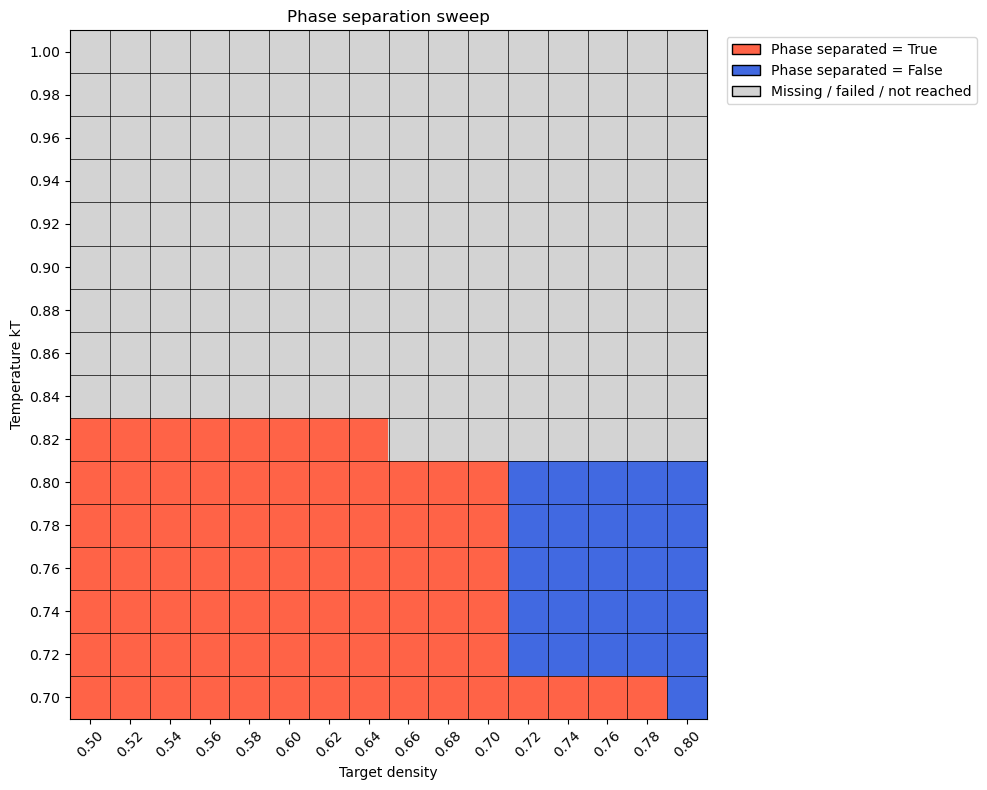

Sweep CSV summary
CSV file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/sweep_summary_kT_0.70_1.00_rho_0.50_0.80_nsteps_1000000.csv
Total grid points:              256
Completed rows:                 104
Failed rows:                    0
Missing / failed / not reached: 152
Phase separated True:           78
Phase separated False:          26


,kT,target_rho,BoxLength,nsteps,log_period,status,created_new,state_path,log_path,N,...,pressure_std_last100,PE_per_particle_mean_last100,PE_per_particle_std_last100,KE_per_particle_mean_last100,KE_per_particle_std_last100,first_timestep_used,last_timestep_used,run_time_seconds,phase_separated_clean,phase_code
0,0.7,0.50,50.0,1000000.0,1000.0,completed,False,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,62500.0,...,0.009604,-5.083471,0.005883,1.050297,0.003603,901000.0,1000000.0,0.014002,True,1
1,0.7,0.52,50.0,1000000.0,1000.0,completed,False,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,62500.0,...,0.009251,-5.117162,0.005211,1.050243,0.003607,901000.0,1000000.0,0.011070,True,1
2,0.7,0.54,50.0,1000000.0,1000.0,completed,False,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,62500.0,...,0.010584,-5.116324,0.005096,1.050195,0.003629,901000.0,1000000.0,0.010370,True,1
3,0.7,0.56,50.0,1000000.0,1000.0,completed,False,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,62500.0,...,0.009920,-5.116098,0.006063,1.050265,0.003688,901000.0,1000000.0,0.011709,True,1
4,0.7,0.58,50.0,1000000.0,1000.0,completed,False,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,70304.0,...,0.009938,-5.121897,0.004677,1.050215,0.003406,901000.0,1000000.0,0.010602,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,1.0,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
252,1.0,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
253,1.0,0.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
254,1.0,0.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


In [2]:
# ============================================================
# Phase separation heat map from sweep CSV
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


# ============================================================
# CSV path
# ============================================================

BoxLength = 50.0

summary_path = (
    THERMALIZED_STATES_ROOT
    / f"BoxLength_{BoxLength:.1f}"
    / "sweep_summary_kT_0.70_1.00_rho_0.50_0.80_nsteps_1000000.csv"
)

df = pd.read_csv(summary_path)


# ============================================================
# Expected sweep grid
# ============================================================

kT_values = np.round(
    np.arange(0.70, 1.00 + 0.001, 0.02),
    2,
)

rho_values = np.round(
    np.arange(0.50, 0.80 + 0.001, 0.02),
    2,
)


# ============================================================
# Clean phase_separated column
# ============================================================

def clean_bool_value(x):
    """
    Convert CSV values like True, False, 'True', 'False', 1, 0, nan
    into actual Python True/False/None.
    """

    if pd.isna(x):
        return None

    if isinstance(x, bool):
        return x

    x_str = str(x).strip().lower()

    if x_str in ["true", "1", "yes"]:
        return True

    if x_str in ["false", "0", "no"]:
        return False

    return None


df["phase_separated_clean"] = df["phase_separated"].apply(clean_bool_value)


# ============================================================
# Build full grid, including points not reached yet
# ============================================================

full_grid = pd.MultiIndex.from_product(
    [kT_values, rho_values],
    names=["kT", "target_rho"],
).to_frame(index=False)

# Keep only the most recent row for each point, in case the CSV has duplicates
df_sorted = df.sort_values(["kT", "target_rho"]).copy()

df_unique = (
    df_sorted
    .drop_duplicates(subset=["kT", "target_rho"], keep="last")
)

plot_df = full_grid.merge(
    df_unique,
    on=["kT", "target_rho"],
    how="left",
)


# ============================================================
# Encode values for heat map
#
# -1 = missing, failed, or not completed yet
#  0 = completed and phase_separated is False
#  1 = completed and phase_separated is True
# ============================================================

def encode_phase_row(row):
    if row.get("status") != "completed":
        return -1

    if row.get("phase_separated_clean") is True:
        return 1

    if row.get("phase_separated_clean") is False:
        return 0

    return -1


plot_df["phase_code"] = plot_df.apply(encode_phase_row, axis=1)


# ============================================================
# Pivot into heat map grid
# ============================================================

heatmap_grid = plot_df.pivot(
    index="kT",
    columns="target_rho",
    values="phase_code",
)

# Sort so lower temperatures are at the bottom of the plot
heatmap_grid = heatmap_grid.sort_index(ascending=True)


# ============================================================
# Plot heat map
# ============================================================

plt.figure(figsize=(10, 8))

# Colors:
# grey  = missing / failed / not reached yet
# blue  = phase_separated False
# red   = phase_separated True
cmap = ListedColormap([
    "lightgray",
    "royalblue",
    "tomato",
])

bounds = [-1.5, -0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.imshow(
    heatmap_grid.values,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

plt.xticks(
    ticks=np.arange(len(heatmap_grid.columns)),
    labels=[f"{rho:.2f}" for rho in heatmap_grid.columns],
    rotation=45,
)

plt.yticks(
    ticks=np.arange(len(heatmap_grid.index)),
    labels=[f"{kT:.2f}" for kT in heatmap_grid.index],
)

plt.xlabel("Target density")
plt.ylabel("Temperature kT")
plt.title("Phase separation sweep")


# ============================================================
# Add grid lines between boxes
# ============================================================

ax = plt.gca()

ax.set_xticks(
    np.arange(-0.5, len(heatmap_grid.columns), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(heatmap_grid.index), 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=0.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ============================================================
# Add legend
# ============================================================

legend_handles = [
    Patch(facecolor="tomato", edgecolor="black", label="Phase separated = True"),
    Patch(facecolor="royalblue", edgecolor="black", label="Phase separated = False"),
    Patch(facecolor="lightgray", edgecolor="black", label="Missing / failed / not reached"),
]

plt.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)

plt.tight_layout()
plt.show()


# ============================================================
# Print quick progress summary
# ============================================================

n_total = len(plot_df)
n_completed = (plot_df["status"] == "completed").sum()
n_failed = (plot_df["status"] == "failed").sum()
n_missing_or_unreached = (plot_df["phase_code"] == -1).sum()
n_phase_true = (plot_df["phase_code"] == 1).sum()
n_phase_false = (plot_df["phase_code"] == 0).sum()

print("=" * 80)
print("Sweep CSV summary")
print("=" * 80)
print("CSV file:", summary_path)
print(f"Total grid points:              {n_total}")
print(f"Completed rows:                 {n_completed}")
print(f"Failed rows:                    {n_failed}")
print(f"Missing / failed / not reached: {n_missing_or_unreached}")
print(f"Phase separated True:           {n_phase_true}")
print(f"Phase separated False:          {n_phase_false}")
print("=" * 80)

plot_df.sort_values(["kT", "target_rho"])

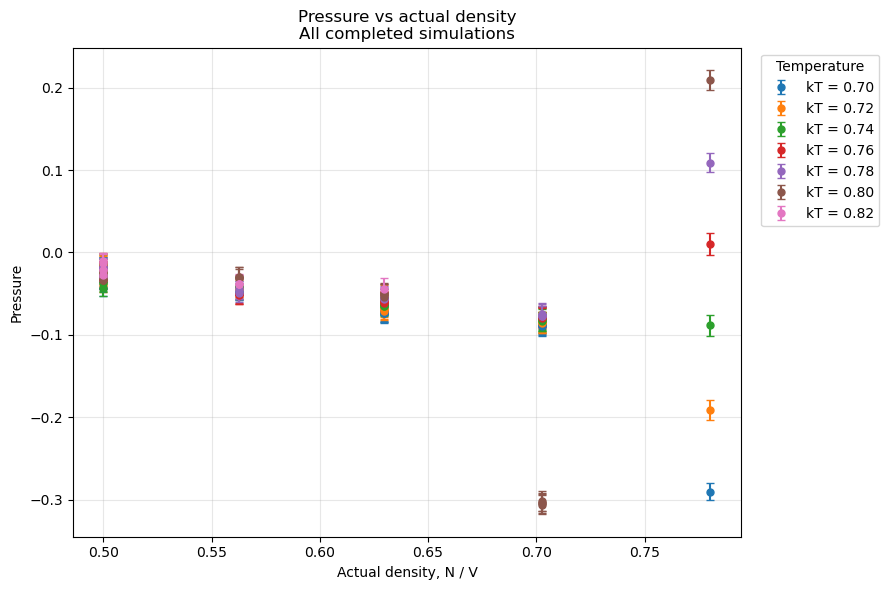

,kT,target_rho,actual_rho,N,pressure_mean_last100,pressure_std_last100,phase_separated,status
0,0.70,0.50,0.500000,62500,-0.043518,0.009604,True,completed
1,0.70,0.52,0.500000,62500,-0.016277,0.009251,True,completed
2,0.70,0.54,0.500000,62500,-0.016637,0.010584,True,completed
3,0.70,0.56,0.500000,62500,-0.015696,0.009920,True,completed
4,0.70,0.58,0.562432,70304,-0.047699,0.009938,True,completed
...,...,...,...,...,...,...,...,...
99,0.82,0.56,0.500000,62500,-0.027625,0.011041,True,completed
100,0.82,0.58,0.562432,70304,-0.037938,0.011071,True,completed
101,0.82,0.60,0.562432,70304,-0.037967,0.012063,True,completed
102,0.82,0.62,0.562432,70304,-0.038075,0.010897,True,completed


In [8]:
# ============================================================
# Scatter plot: pressure or PE/N or KE/N vs actual density
# One color per temperature
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


# ============================================================
# Choose CSV file
# ============================================================

BoxLength = 50.0

summary_path = (
    THERMALIZED_STATES_ROOT
    / f"BoxLength_{BoxLength:.1f}"
    / "sweep_summary_kT_0.70_1.00_rho_0.50_0.80_nsteps_1000000.csv"
)

df = pd.read_csv(summary_path)


# ============================================================
# Choose quantity to plot
# ============================================================

quantity_to_plot = "pressure"
# Options:
#   "pressure"
#   "PE_per_particle"
#   "KE_per_particle"


# ============================================================
# Clean and filter dataframe
# ============================================================

df_plot = df.copy()

# Keep only finished simulations
df_plot = df_plot[df_plot["status"] == "completed"].copy()

# Compute actual density from N / V
df_plot["actual_rho"] = df_plot["N"] / df_plot["BoxLength"]**3

# Sort for cleaner plotting
df_plot = df_plot.sort_values(["kT", "actual_rho"]).copy()


# ============================================================
# Choose y quantity and uncertainty
# ============================================================

quantity_map = {
    "pressure": {
        "mean_col": "pressure_mean_last100",
        "std_col": "pressure_std_last100",
        "ylabel": "Pressure",
        "title": "Pressure vs actual density",
    },
    "PE_per_particle": {
        "mean_col": "PE_per_particle_mean_last100",
        "std_col": "PE_per_particle_std_last100",
        "ylabel": "PE / N",
        "title": "Potential energy per particle vs actual density",
    },
    "KE_per_particle": {
        "mean_col": "KE_per_particle_mean_last100",
        "std_col": "KE_per_particle_std_last100",
        "ylabel": "KE / N",
        "title": "Kinetic energy per particle vs actual density",
    },
}

if quantity_to_plot not in quantity_map:
    raise ValueError(
        "quantity_to_plot must be one of: "
        f"{list(quantity_map.keys())}"
    )

mean_col = quantity_map[quantity_to_plot]["mean_col"]
std_col = quantity_map[quantity_to_plot]["std_col"]
ylabel = quantity_map[quantity_to_plot]["ylabel"]
title = quantity_map[quantity_to_plot]["title"]

# Drop rows where this quantity is missing
df_plot = df_plot.dropna(
    subset=["actual_rho", "kT", mean_col, std_col]
).copy()


# ============================================================
# Plot all completed simulations, grouped by temperature
# ============================================================

plt.figure(figsize=(9, 6))

for kT, group in df_plot.groupby("kT"):
    group = group.sort_values("actual_rho")

    plt.errorbar(
        group["actual_rho"],
        group[mean_col],
        yerr=group[std_col],
        fmt="o",
        linestyle="none",
        capsize=3,
        markersize=5,
        label=f"kT = {kT:.2f}",
    )

plt.xlabel("Actual density, N / V")
plt.ylabel(ylabel)
plt.title(f"{title}\nAll completed simulations")

plt.grid(alpha=0.3)

plt.legend(
    title="Temperature",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


# ============================================================
# Show plotted rows
# ============================================================

display_cols = [
    "kT",
    "target_rho",
    "actual_rho",
    "N",
    mean_col,
    std_col,
    "phase_separated",
    "status",
]

df_plot[display_cols]